## 1. Import Functions

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import folium
import webbrowser
import numpy as np 
import seaborn as sns
from itertools import combinations
from collections import Counter
from scipy.stats import pearsonr
from mlxtend.frequent_patterns import apriori, association_rules
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import re
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, PatternFill
from openpyxl.utils import get_column_letter
import math
from openpyxl import Workbook


## 2. Import Data

In [16]:
base_path = r"C:/Users/20212883/OneDrive - TU Eindhoven/02. TUE/01. Year 5 (2024-2025)/00. BEP/"

order_items_path = base_path + "order_items.csv"
orders_path = base_path + "orders.csv"
packaging_path = base_path + "packaging_registrations.csv"
orders_coord_path = base_path + "orders_split.xlsx"

In [17]:
df_order_items = pd.read_csv(order_items_path)
df_orders = pd.read_csv(orders_path)
df_packaging = pd.read_csv(packaging_path)
df_orders_coordinaten = pd.read_excel(orders_coord_path) 

In [18]:
#When adding updated datafiles, make sure it still has the following structure of columns: 

In [19]:
print(df_order_items.columns)

Index(['order_item_id', 'order_id', 'supplier_id', 'supplier_location',
       'product_id', 'product_name', 'product_category', 'quantity_units',
       'price', 'quantity_kg', 'unit_type', 'packaging_type', 'fragile_flag',
       'stackable_flag', 'avg_unit_weight'],
      dtype='str')


In [20]:
print(df_orders.columns)

Index(['order_id', 'order_date', 'delivery_date', 'customer_id',
       'customer_type', 'delivery_location', 'total_items', 'total_weight_kg'],
      dtype='str')


In [21]:
print(df_packaging.columns)

Index(['supplier_id', 'supplier_name', 'registration_date', 'hub_id',
       'crate_type_id', 'crate_type_code', 'crate_type', 'incoming_count',
       'outgoing_count', 'balance_delta', 'crate_price', 'balance_value'],
      dtype='str')


In [22]:
print(df_orders_coordinaten.columns)

Index(['order_id', 'order_date', 'delivery_date', 'customer_id',
       'customer_type', 'delivery_location', 'Unnamed: 6', 'total_items',
       'total_weight_kg'],
      dtype='str')


## 3. Data Cleaning of the Categories in Order_items

In [23]:
df_order_items_cleaned = df_order_items.copy()

In [24]:
# Sorting the categories and save it to df_order_item_cleaned

In [25]:
category_map = {
    'Zuivel': 'Dairy',
    'Groente': 'Vegetables', 
    'Eieren':'Eggs',
    'Vleeswaren': 'Cold cuts', 
    'Varken': 'Pork',
    'Rund':'Beef',
    'Kip': 'Chicken', 
    'Salades':'Salads', 
    'Geitenzuivel': 'Goat dairy',
    'Kaas': 'Cheese',
    'Kaas vacuüm op gewicht': 'Cheese',
    'Hele wielen': 'Cheese',
    'Gesneden kaas - plakken': 'Cheese',
    'Jurrius Fruit': 'Fruit', 
    'Handfruit': 'Fruit', 
    'Boter': 'Dairy', 
    'Fruit & conserven': 'Fruit',
    'Fruitconserven': 'Fruit', 
    'Aardappel':'Potato',
    'Bakproducten':'Baked goods', 
    'Honing':'Honey',
    'Boerenijs' : 'Icecream', 
    'Paddenstoelen': 'Vegetables',
    'Het Kruidenrijk': 'Spices', 
    'Philips Fruittuin': 'Fruit', 
    'Kersenhof': 'Fruit',
    'Beemster Garlic': 'Spices',
    'Zaaipakketten' : 'Other', 
    'Crackers & beschuit' : 'Other',
    'Chips' : 'Other',
    'Vers fruit & conserven': 'Fruit',
    'Worstenbroodjes': 'Bread',
    'Gevuld brood': 'Bread',
    'Desem & spelt': 'Bread',
    'Smaak Geheimen' : 'Other',
    'Brassica' : 'Other',
    'Kiooms' : 'Other',
    'Schulp' : 'Other',
    'Fruit': 'Fruit', 
    'Bonen':'Vegetables', 
    'Bier' : 'Alcoholic drinks',
    'Wijnen & Ciders': 'Alcoholic drinks', 
    'Jan Bax': 'Sauces', 
    'Imkerij de Walhut': 'Honey', 
    'Kroketten & bitterballen': 'Fry', 
    'Hanne Hoeve': 'Nuts',
    'Walnoten': 'Nuts',
    'Bitterballen & kroketten': 'Fry', 
    'Saanenhof': 'Goat dairy', 
    'Verse kruiden': 'Spices',
    'Geitenkaas': 'Goat dairy',
    'Hotelblok - paal zonder korst - broodjes': 'Cheese',
    'Koek': 'Other',
    'Searoop': 'Other',
    'Stuksprijs artikelen': 'Cheese', 
    'Kant & klaar': 'Ready made meals', 
    'OUD ARTIKEL': 'Other',
    'Biologisch vlees':'Biological meat', 
    'Soepen': 'Soups',
    'Sap':'Juice', 
    'Noten' :'Nuts',
    'Vlees (stuksprijzen)': 'Other',
    'Koude sauzen':'Other'
}

# NOTE: the catch-all map is applied AFTER the name-based refinements below
# (at the end of the meat-reclassification cell), so those rules are no
# longer overridden by a blanket remap.

In [26]:
df = df_order_items_cleaned 

df.loc[
    (df['product_category'] == 'Stuksprijs artikelen') & 
    (df['product_name'].str.contains('Kaas', case=False, na=False)),
    'product_category'
] = 'Cheese'

df.loc[
    (df['product_category'] == 'Aardappelen, friet & uien') & 
    (df['product_name'].str.contains('ui', case=False, na=False)),
    'product_category'
] = 'Vegetables'

df.loc[
    (df['product_category'] == 'Aardappelen, friet & uien') & 
    (df['product_name'].str.contains('friet', case=False, na=False)),
    'product_category'
] = 'Fry'

df.loc[
    (df['product_category'] == 'Aardappelen, friet & uien') & 
    (~df['product_name'].str.contains('ui|friet', case=False, na=False)),
    'product_category'
] = 'Potato'

df.loc[
    (df['product_category'] == 'Aardappel & groente') & 
    (df['product_name'].str.contains('ardappel', case=False, na=False)),
    'product_category'
] = 'Potato'

df.loc[
    (df['product_category'] == 'Aardappel & groente') & 
    (~df['product_name'].str.contains('ardappel', case=False, na=False)),
    'product_category'
] = 'Vegetables'

In [27]:
meat_map = ['Kant & klaar', 'OUD ARTIKEL', 'Vlees (stuksprijzen)']

for cat in meat_map:
    df.loc[
        (df['product_category'] == cat) &
        (df['product_name'].str.contains('kip', case=False, na=False)),
        'product_category'
    ] = 'Chicken'

    df.loc[
        (df['product_category'] == cat) &
        (df['product_name'].str.contains('varken', case=False, na=False)),
        'product_category'
    ] = 'Pork'

    df.loc[
        (df['product_category'] == cat) &
        (df['product_name'].str.contains('rund', case=False, na=False)),
        'product_category'
    ] = 'Beef'

# Catch-all: map every remaining (raw) category to its English bucket.
# Runs AFTER the refinements above, so meat sold under 'Kant & klaar' /
# 'OUD ARTIKEL' / 'Vlees (stuksprijzen)' keeps its Chicken/Pork/Beef label,
# while any unrefined rows (e.g. non-Kaas 'Stuksprijs artikelen') still land
# in a known category.
df_order_items_cleaned['product_category'] = (
    df_order_items_cleaned['product_category'].replace(category_map)
)


## 4. Creating customer order

In [28]:
# Step 1. Nieuwe excel customer_order_id
df_orders_cleaned = df_orders.copy()

# Step 2. Set dataset good 
df_orders_cleaned['delivery_date'] = pd.to_datetime(
    df_orders_cleaned['delivery_date'],
    dayfirst=True
)

# Step 3. Making a customer order id, when an order has the same delivery_date, customer_id and delivery_locatoin
df_orders_cleaned["customer_order_id"] = (
    df_orders_cleaned.groupby(["delivery_date", "customer_id", "delivery_location"])
    .ngroup() + 1
)

# Step 4. Sort values based on customer order id and making it the first column
df_orders_cleaned = df_orders_cleaned.sort_values(by="customer_order_id")
cols = ["customer_order_id"] + [col for col in df_orders_cleaned.columns if col != "customer_order_id"]
df_orders_cleaned = df_orders_cleaned[cols]

# Step 5. Making order id intergers for safety
df_orders_cleaned["order_id"] = df_orders_cleaned["order_id"].astype(int)
df_order_items_cleaned["order_id"] = df_order_items_cleaned["order_id"].astype(int)

# Step 6. Save orders_cleaned in output excel  
df_orders_cleaned.to_excel("output.xlsx", index=False)


# Step 7. Merge orders_cleaned with order_item_cleaned
df_order_items_cleaned = df_order_items_cleaned.merge(
    df_orders_cleaned[["order_id", "customer_order_id"]],
    on="order_id",
    how="left"
)

# Step 8. Sort values based on customer order id and making it first column in items 
df_order_items_cleaned = df_order_items_cleaned.sort_values(
    by=["customer_order_id", "order_id", "order_item_id"]
)

cols = ["customer_order_id"] + [col for col in df_order_items_cleaned.columns if col != "customer_order_id"]
df_order_items_cleaned = df_order_items_cleaned[cols]


# Step 9. Calculating total price 
df_order_items_cleaned['total_price'] = (
    df_order_items_cleaned['quantity_units'] * df_order_items_cleaned['price']
)

# Step 10. Save order_items_cleaned in output excel
df_order_items_cleaned.to_excel("output_items.xlsx", index=False)

## 5. Orders deleted which have a negative value as price

In [29]:
ids_to_remove = [813729, 819693]
df_orders_cleaned = df_orders_cleaned[
    ~df_orders_cleaned["order_id"].isin(ids_to_remove)
]

df_order_items_cleaned = df_order_items_cleaned[
    ~df_order_items_cleaned["order_id"].isin(ids_to_remove)
]

df_orders_cleaned = df_orders_cleaned.reset_index(drop=True)
df_order_items_cleaned = df_order_items_cleaned.reset_index(drop=True)

## 6. Connecting packaging data with customer order 

In [30]:
# Step 1. Ensure datetime formats
# NOTE: df_orders_cleaned is REUSED from Sections 4-5 here. It already has
# customer_order_id (numbered over the full order set) and the negative-price
# orders removed (Section 5). We deliberately do NOT rebuild it from df_orders,
# so that filtering stays applied and the IDs stay in sync with
# df_order_items_cleaned (Section 8 matches the two tables on customer_order_id).
df_packaging_cleaned = df_packaging.copy()

df_packaging_cleaned["registration_date"] = pd.to_datetime(
    df_packaging_cleaned["registration_date"],
    format="%d.%m.%Y"
)

df_orders_cleaned["order_date"] = pd.to_datetime(
    df_orders_cleaned["order_date"],
    format="%d.%m.%Y %H:%M:%S"
)

df_orders_cleaned["delivery_date"] = pd.to_datetime(
    df_orders_cleaned["delivery_date"],
    dayfirst=True
)

# Step 2. Extract ISO week/year
pkg_iso = df_packaging_cleaned["registration_date"].dt.isocalendar()
df_packaging_cleaned["week"] = pkg_iso.week.astype(int)
df_packaging_cleaned["year"] = pkg_iso.year.astype(int)

ord_iso = df_orders_cleaned["order_date"].dt.isocalendar()
df_orders_cleaned["week"] = ord_iso.week.astype(int)
df_orders_cleaned["year"] = ord_iso.year.astype(int)

# Step 3. Order ids as integers
# (customer_order_id already exists from Section 4, and the negative-price
#  orders were already dropped in Section 5 — nothing to rebuild or re-remove.)
df_orders_cleaned["order_id"] = df_orders_cleaned["order_id"].astype(int)
df_order_items["order_id"] = df_order_items["order_id"].astype(int)

# Step 4. Merge supplier into orders via order_items
df_order_items["customer_order_id"] = df_order_items_cleaned["order_id"].map(
    df_orders_cleaned.set_index("order_id")["customer_order_id"]
)

df_orders_with_supplier = df_orders_cleaned.drop(columns=["customer_order_id"]).merge(
    df_order_items_cleaned[["order_id", "supplier_id", "customer_order_id"]].drop_duplicates(),
    on="order_id",
    how="left"
)

# Step 5. Expand orders for week OR previous week match (and make sure +1 crosses into a new year goes also right)

def next_week(row):
    date = row["order_date"] + pd.Timedelta(weeks=1)
    iso = date.isocalendar()
    return pd.Series({"match_week": iso.week, "match_year": iso.year})

orders_current = df_orders_with_supplier.copy()
orders_current["match_week"] = orders_current["week"]
orders_current["match_year"] = orders_current["year"]

orders_prev = df_orders_with_supplier.copy()
next_week_info = orders_prev.apply(next_week, axis=1)
orders_prev["match_week"] = next_week_info["match_week"].astype(int)
orders_prev["match_year"] = next_week_info["match_year"].astype(int)

orders_expanded = pd.concat([orders_current, orders_prev], ignore_index=True)

# Step 6. Adding customer order id when order date is in the same week or 1 week earlier as registration date of the hub
df_packaging_cleaned = df_packaging_cleaned.merge(
    orders_expanded[[
        "match_week", "match_year",
        "supplier_id",
        "customer_order_id"
    ]].drop_duplicates(),
    left_on=["week", "year", "supplier_id"],
    right_on=["match_week", "match_year", "supplier_id"],
    how="left"
)

# Step 7. ?? 
# FIX: deduplicate so each packaging registration links to at most one order
# Keep the match whith the earliest registration date
if "registration_date" in df_packaging_cleaned.columns:
    # find the primary key of df_packaging — adjust if yours is named differently
    pkg_id_col = df_packaging_cleaned.columns[0]
    df_packaging_cleaned = (
        df_packaging_cleaned
        .sort_values("registration_date")
        .drop_duplicates(subset=[pkg_id_col], keep="first")
    )

# Step 8. Summary 
missing_orders = df_orders_with_supplier["customer_order_id"].isna().sum()
print(f"Orders missing customer_order_id: {missing_orders}" if missing_orders > 0 else "✅ All orders have customer_order_id")

missing_pkg = df_packaging_cleaned["customer_order_id"].isna().sum()
print(f"Packaging missing customer_order_id: {missing_pkg}" if missing_pkg > 0 else "✅ All packaging matched")

multi = df_packaging_cleaned.groupby(df_packaging_cleaned.columns[0])["customer_order_id"].nunique()
print(f"Registrations matched >1 order (before dedup): {(multi > 1).sum()}")

# 9. Saving packaging file to output in excel 
df_packaging_cleaned.to_excel("output_packaging.xlsx", index=False)

Orders missing customer_order_id: 4
Packaging missing customer_order_id: 1
Registrations matched >1 order (before dedup): 0


## 7. Splitting prices into price_per_kg, price_per_L or price_per_piece

In [31]:
#Can packaging_type be parsed?
#│
#├── YES
#│     → use packaging_type result
#│
#└── NO
#      │
#      ├── quantity_kg is real
#      │      → use quantity_kg
#      │
#      └── quantity_kg is dummy
#             → no package size available

# Step 1: Seeing which quantity_kg is a dummy variable
print("\n=== STEP 1: quantity_kg column analysis ===")
df_order_items_cleaned['qty_kg_is_dummy'] = (
    (df_order_items_cleaned['quantity_kg'] - df_order_items_cleaned['quantity_units'] * 0.001).abs() < 1e-9
)
print("Rows where quantity_kg is a dummy placeholder :", df_order_items_cleaned['qty_kg_is_dummy'].sum())
print("Rows where quantity_kg is real weight         :", (~df_order_items_cleaned['qty_kg_is_dummy']).sum())


# Step 2: Splitting all strings in packaging_type
def parse_packaging(s):
    if pd.isna(s):
        return None

    s_clean = str(s).strip().lower()
    s_clean = s_clean.replace(',', '.')          # "1,5 kg" -> "1.5 kg"
    s_clean = re.sub(r'\s+', ' ', s_clean)       # collapse whitespace

    # 2a. Multiplied packs
    multi = re.search(
        r'(\d+\.?\d*)\s*[x\*]\s*(\d+\.?\d*)\s*(g|gr|gram|kg|ml|l|cl|liter|litre)',
        s_clean
    )
    if multi:
        total = float(multi.group(1)) * float(multi.group(2))
        return _convert(total, multi.group(3), s)

    # 2b. Stuks + individual weight  "4 stuks a 90gr/st"
    stuks_weight = re.search(
        r'(\d+\.?\d*)\s*stuks?\s*a\s*(\d+\.?\d*)\s*(g|gr|gram|kg)', s_clean
    )
    if stuks_weight:
        total = float(stuks_weight.group(1)) * float(stuks_weight.group(2))
        return _convert(total, stuks_weight.group(3), s)

    # 2c. Stuks + total weight  "2 stuks - ca. 200 g"
    stuks_total = re.search(
        r'(\d+\.?\d*)\s*stuks?\s*[-]\s*(?:ca\.?\s*)?(\d+\.?\d*)\s*(g|gr|gram|kg)', s_clean
    )
    if stuks_total:
        n_pieces = float(stuks_total.group(1))
        result = _convert(float(stuks_total.group(2)), stuks_total.group(3), s)
        if result:
            result['n_pieces'] = n_pieces
        return result

    # 2d. Plain weight / volume (with optional "ca." or "ong.")
    plain = re.search(
        r'(?:ca\.?\s*|ong\.?\s*)?(\d+\.?\d*)\s*(g|gr|gram|kg|ml|l|cl|liter|litre)',
        s_clean
    )
    if plain:
        return _convert(float(plain.group(1)), plain.group(2), s)

    # 2e. Pure piece counts  ("90 stuks", "per stuk")
    pieces = re.search(r'(\d+\.?\d*)\s*stuks?', s_clean)
    if pieces:
        n = float(pieces.group(1))
        return {'amount': n, 'unit': 'stuks', 'n_pieces': n, 'source': 'packaging_type'}
    if any(s_clean.startswith(p) for p in ('per stuk', 'per krop', 'per bosje', '1 stuk', '1 bol', '1 brood', '1 doos', 'zakje diepvries')):
        return {'amount': 1.0, 'unit': 'stuks', 'n_pieces': 1.0, 'source': 'packaging_type'}
    if s_clean.startswith('per liter'):
        return {'amount': 1.0, 'unit': 'L', 'source': 'packaging_type'}
    if s_clean.startswith('per kg'):
        return {'amount': 1.0, 'unit': 'kg', 'source': 'packaging_type'}
    return None


def _convert(amount, unit_raw, raw_s):
    """Normalise to kg or litres."""
    u = unit_raw.lower().strip('.')
    if u in ('g', 'gr', 'gram'):
        return {'amount': amount / 1000, 'unit': 'kg',  'source': 'packaging_type'}
    if u == 'kg':
        return {'amount': amount, 'unit': 'kg',  'source': 'packaging_type'}
    if u == 'ml':
        return {'amount': amount / 1000, 'unit': 'L', 'source': 'packaging_type'}
    if u == 'cl':
        return {'amount': amount / 100,   'unit': 'L', 'source': 'packaging_type'}
    if u in ('l', 'liter', 'litre'):
        return {'amount': amount, 'unit': 'L', 'source': 'packaging_type'}
    return None


# Step 3: Apply packaging_type parser (packaging_type is parseable)
print("\n=== STEP 3: Parse packaging_type ===")
parsed = df_order_items_cleaned['packaging_type'].apply(parse_packaging)

df_order_items_cleaned['pkg_amount'] = parsed.apply(lambda x: x['amount']             if x else None)
df_order_items_cleaned['pkg_unit']   = parsed.apply(lambda x: x['unit']               if x else None)
df_order_items_cleaned['pkg_source'] = parsed.apply(lambda x: x['source']             if x else None)
df_order_items_cleaned['n_pieces']   = parsed.apply(lambda x: x.get('n_pieces', None) if x else None)

n_parsed = df_order_items_cleaned['pkg_amount'].notna().sum()
print(f"Parsed from packaging_type : {n_parsed} / {len(df_order_items_cleaned)}  ({n_parsed/len(df_order_items_cleaned)*100:.1f} %)")
print("\nUnit distribution:")
print(df_order_items_cleaned['pkg_unit'].value_counts())
print(f"\nStill unparsed: {df_order_items_cleaned['pkg_amount'].isna().sum()} rows")


# Step 4: Fill unparsed rows using quantity_kg (packaging_type unpareseable + quantity_kg is real or packaging_type unperseable + quantity_tyep dummy)
print("\n=== STEP 4: Fallback — fill unparsed rows from quantity_kg ===")

qty_kg_mask = (
    df_order_items_cleaned['pkg_amount'].isna()
    & ~df_order_items_cleaned['qty_kg_is_dummy']
    & (df_order_items_cleaned['quantity_kg'] > 0.001)
)

df_order_items_cleaned.loc[qty_kg_mask, 'pkg_amount'] = df_order_items_cleaned.loc[qty_kg_mask, 'quantity_kg']
df_order_items_cleaned.loc[qty_kg_mask, 'pkg_unit']   = 'kg'
df_order_items_cleaned.loc[qty_kg_mask, 'pkg_source'] = 'quantity_kg'

n_after  = df_order_items_cleaned['pkg_amount'].notna().sum()
n_filled = qty_kg_mask.sum()
print(f"Rows filled via quantity_kg : {n_filled}")
print(f"Total parsed after fallback : {n_after} / {len(df_order_items_cleaned)}  ({n_after/len(df_order_items_cleaned)*100:.1f} %)")
print(f"Still unparsed              : {df_order_items_cleaned['pkg_amount'].isna().sum()} rows")
print("\nSource breakdown:")
print(df_order_items_cleaned['pkg_source'].value_counts())

print("\nSample of quantity_kg fallback rows:")
print(
    df_order_items_cleaned[qty_kg_mask][['product_name', 'packaging_type',
                     'quantity_kg', 'pkg_amount', 'pkg_unit', 'pkg_source']]
    .drop_duplicates('product_name')
    .head(20)
    .to_string()
)


# Step 5: Calculate price per base unit
print("\n=== STEP 5: Price per base unit ===")

mask       = df_order_items_cleaned['pkg_amount'].notna() & (df_order_items_cleaned['pkg_amount'] > 0)
g_mask     = mask & (df_order_items_cleaned['pkg_unit'] == 'kg')
ml_mask    = mask & (df_order_items_cleaned['pkg_unit'] == 'L')

piece_mask = (
    df_order_items_cleaned['n_pieces'].notna()
    & (df_order_items_cleaned['n_pieces'] > 0)
    & (df_order_items_cleaned['pkg_unit'] == 'stuks')
)

df_order_items_cleaned.loc[mask,       'price_per_unit']  = df_order_items_cleaned.loc[mask,       'price'] / df_order_items_cleaned.loc[mask,       'pkg_amount']
df_order_items_cleaned.loc[g_mask,     'price_per_kg']    = df_order_items_cleaned.loc[g_mask,     'price_per_unit']
df_order_items_cleaned.loc[ml_mask,    'price_per_L']     = df_order_items_cleaned.loc[ml_mask,    'price_per_unit']
df_order_items_cleaned.loc[piece_mask, 'price_per_piece'] = df_order_items_cleaned.loc[piece_mask, 'price'] / df_order_items_cleaned.loc[piece_mask, 'n_pieces']

print(df_order_items_cleaned[mask][['product_name', 'packaging_type', 'pkg_source', 'price',
                'pkg_amount', 'pkg_unit', 'n_pieces',
                'price_per_kg', 'price_per_L', 'price_per_piece']].head(25).to_string())

print("\nRows with price_per_kg    :", df_order_items_cleaned['price_per_kg'].notna().sum())
print("Rows with price_per_L     :", df_order_items_cleaned['price_per_L'].notna().sum())
print("Rows with price_per_piece :", df_order_items_cleaned['price_per_piece'].notna().sum())


# Step 6: Build a comparable price table per product
print("\n=== STEP 6: Average comparable price per product ===")

price_table = (
    df_order_items_cleaned[mask]
    .groupby(['product_name', 'pkg_unit'])
    .agg(
        avg_price           = ('price',          'mean'),
        avg_pkg_amount_g    = ('pkg_amount',      'mean'),
        avg_price_per_unit  = ('price_per_unit', 'mean'),
        avg_price_per_kg_L  = ('price_per_kg',   'mean'),
        avg_price_per_piece = ('price_per_piece','mean'),
        n_orders            = ('price',          'count'),
        sources             = ('pkg_source',     lambda x: '/'.join(sorted(x.dropna().unique())))
    )
    .reset_index()
    .sort_values(['pkg_unit', 'avg_price_per_unit'])
)


ml_rows = price_table['pkg_unit'] == 'L'
price_table.loc[ml_rows, 'avg_price_per_kg_L'] = (
    df_order_items_cleaned[ml_mask]
    .groupby('product_name')['price_per_L']
    .mean()
    .reindex(price_table.loc[ml_rows, 'product_name'])
    .values
)

df_order_items_cleaned['total_price'] = (
    df_order_items_cleaned['quantity_units']
    * df_order_items_cleaned['price']
)

cols = ['customer_order_id'] + [
    col for col in df_order_items_cleaned.columns
    if col != 'customer_order_id'
]
df_order_items_cleaned = df_order_items_cleaned[cols]

df_order_items_cleaned = df_order_items_cleaned.sort_values(
    by='customer_order_id', ascending=True
).reset_index(drop=True)

df_order_items_cleaned.to_excel("output_items_price_splitted.xlsx", index=False)


=== STEP 1: quantity_kg column analysis ===
Rows where quantity_kg is a dummy placeholder : 17216
Rows where quantity_kg is real weight         : 3745

=== STEP 3: Parse packaging_type ===
Parsed from packaging_type : 19234 / 20961  (91.8 %)

Unit distribution:
pkg_unit
L        10924
kg        6531
stuks     1779
Name: count, dtype: int64

Still unparsed: 1727 rows

=== STEP 4: Fallback — fill unparsed rows from quantity_kg ===
Rows filled via quantity_kg : 1696
Total parsed after fallback : 20930 / 20961  (99.9 %)
Still unparsed              : 31 rows

Source breakdown:
pkg_source
packaging_type    19234
quantity_kg        1696
Name: count, dtype: int64

Sample of quantity_kg fallback rows:
                               product_name             packaging_type  quantity_kg  pkg_amount pkg_unit   pkg_source
1                             Runderburgers         gewicht naar keuze         0.15        0.15       kg  quantity_kg
51                     Rauwe ham - Gesneden         gewicht n

In [32]:
unparsed_mask = df_order_items_cleaned['pkg_amount'].isna()

print(f"Total unparsed rows: {unparsed_mask.sum()}")

print(df_order_items_cleaned[unparsed_mask][['product_name', 'packaging_type', 'quantity_kg', 'quantity_units']].to_string())

Total unparsed rows: 31
                             product_name                 packaging_type  quantity_kg  quantity_units
643         Eierverpakking voor 10 eieren  Eierverpakking voor 10 eieren        0.001               1
4621        Eierverpakking voor 10 eieren  Eierverpakking voor 10 eieren        0.001               1
4624         Eierverpakking voor 6 eieren   Eierverpakking voor 6 eieren        0.001               1
4981         Eierverpakking voor 6 eieren   Eierverpakking voor 6 eieren        0.001               1
4983        Eierverpakking voor 10 eieren  Eierverpakking voor 10 eieren        0.001               1
6693        Eierverpakking voor 10 eieren  Eierverpakking voor 10 eieren        0.001               1
6838                           Raapstelen                 10 in een krat        0.001               1
9055         Eierverpakking voor 6 eieren   Eierverpakking voor 6 eieren        0.001               1
10679               Extra besteld product                 

## 8. Weight per Row

In [33]:
# Step 1: Attach delivery_date → ISO year/week
date_map = (
    df_orders_cleaned[["customer_order_id", "delivery_date"]]
    .drop_duplicates()
)
 
df_crate = df_order_items_cleaned.merge(date_map, on="customer_order_id", how="left")
 
df_crate["delivery_date"] = pd.to_datetime(df_crate["delivery_date"], dayfirst=True)
iso = df_crate["delivery_date"].dt.isocalendar()
df_crate["iso_year"] = iso.year.astype(int)
df_crate["iso_week"] = iso.week.astype(int)
 
print(f"ISO weeks found: {df_crate['iso_week'].nunique()} weeks "
      f"({df_crate['iso_year'].min()}-W{df_crate['iso_week'].min():02d} "
      f"→ {df_crate['iso_year'].max()}-W{df_crate['iso_week'].max():02d})")

ISO weeks found: 52 weeks (2025-W01 → 2026-W52)


In [34]:
# Step 2: Manual weight lookup for products sold per piece without real weight observations
weight_lookup = {
    "Afbak donker desembrood spelt":                         0.400,
    "Andijvie":                                              0.400,
    "Bladsla":                                               0.200,
    "Bloemkool":                                             0.800,
    "Boeren bitterballen":                                   0.025,
    "Boeren rundvleesbitterballen":                          0.025,
    "Boeren rundvleeskroketten":                             0.050,
    "Boerenkool":                                            0.400,
    "Bospeen":                                               0.300,
    "Bosui":                                                 0.100,
    "Buffel bonbon":                                         0.010,
    "Buffelmozzarella":                                      0.125,
    "Courgette":                                             0.300,
    "Courgette - geel":                                      0.300,
    "Courgette - groen":                                     0.300,
    "Duinboeren kaaskroketten 16 stuks ":                    0.800,
    "Duinboeren kaaskroketten 4 st":                         0.200,
    "Eieren L/M bruin":                                      0.630,
    "Eieren M bruin":                                        0.600,
    "Eieren S bruin":                                        0.500,
    "Eieren XL bruin":                                       0.730,
    "Eieren bio S/M/L/XL bruin":                             0.620,
    "Eikenblad sla":                                         0.200,
    "Eikenblad sla - rood":                                  0.200,
    "Eikenbladsla - groen":                                  0.200,
    "Eikenbladsla - rood ":                                  0.200,
    "Flespompoen":                                           1.200,
    "Gedroogde borrel worst met hazelnoot":                  0.050,
    "Gedroogde worst - Provencaalse kruiden":                0.100,
    "Gildehoen kiploempia's":                                0.080,
    "Groenlof":                                              0.300,
    "Hokkaidopompoen":                                       1.000,
    "Kaneelkoek":                                            0.030,
    "Knolselderij":                                          0.600,
    "Komkommer":                                             0.400,
    "Koolrabi":                                              0.300,
    "Koolrabi paars":                                        0.300,
    "Kropsla":                                               0.300,
    "Lollo Bionda":                                          0.200,
    "Lollo Rossa":                                           0.200,
    "Los flesje diverse smaken":                             0.330,
    "Mergpijpjes":                                           0.200,
    "Mini buffelmozzarella bolletjes":                       0.125,
    "Oesterzwam bitterballen":                               0.025,
    "Oesterzwam kroketten":                                  0.050,
    "Oranje bloemkool":                                      0.800,
    "Paarse bloemkool":                                      0.800,
    "Paaseieren (gekookt)":                                  0.060,
    "Paksoi":                                                0.300,
    "Paprika - geel":                                        0.200,
    "Paprika - rood":                                        0.200,
    "Peper - geel":                                          0.100,
    "Peterselie - krul":                                     0.080,
    "Peterselie Blad":                                       0.080,
    "Peterselie Krul":                                       0.080,
    "Pompoen":                                               1.000,
    "Puntpaprika  - rood":                                   0.150,
    "Raapstelen":                                            0.200,
    "Radicchio rosso":                                       0.300,
    "Rode kool":                                             1.000,
    "Rundervinken":                                          0.150,
    "Salanova - groen":                                      0.200,
    "Sateestokjes varken":                                    0.100,
    "Seizoenskoek":                                          0.030,
    "Selderij":                                              0.300,
    "Snijbiet":                                              0.200,
    "Spaghettipompoen":                                      1.000,
    "Spelt broodje met zonnebloempitten (Van Gogh Broodje)": 0.080,
    "Spitskool":                                             0.800,
    "Sprouting paarse broccoli":                             0.300,
    "Stengelui/bosui":                                       0.100,
    "Suikermais":                                            0.250,
    "Suikermikje":                                           0.030,
    "Venkel":                                                0.300,
    "Worstenbrood":                                          0.120,
    "Worstenbrood diepvries":                                0.120,
    "mergpijpje":                                            0.200,
}
 

In [35]:
# Step 3: Compute avg_weight_per_piece 
df_crate["product_name"] = df_crate["product_name"].str.strip()

reliable_stuks = (
    (df_crate["pkg_unit"] == "stuks")
    & (~df_crate["qty_kg_is_dummy"])
    & (df_crate["quantity_kg"] > 0.001)
    & (df_crate["quantity_units"] > 0)
)

# FIX: always initialise the column so the merge result is never missing
# If no reliable rows exist the column will be all-NaN, which is fine —
# we fall back to the lookup in the next step.
df_crate["weight_per_piece"] = np.where(
    reliable_stuks,
    df_crate["quantity_kg"] / df_crate["quantity_units"],
    np.nan,
)

avg_weight_per_piece = (
    df_crate[reliable_stuks]
    .groupby("product_name")["weight_per_piece"]
    .mean()
    .rename("avg_weight_per_piece")
)

# Map the per-product average back (no merge needed — avoids duplicate columns)
df_crate["avg_weight_per_piece"] = df_crate["product_name"].map(avg_weight_per_piece)

# Fill remaining gaps from the manual lookup
df_crate["avg_weight_per_piece"] = df_crate["avg_weight_per_piece"].fillna(
    df_crate["product_name"].map(weight_lookup)
)

# Step 4: Compute line_weight_kg (vectorised)
is_kg_l   = df_crate["pkg_unit"].isin(["kg", "L"])
is_stuks  = df_crate["pkg_unit"] == "stuks"
has_pkg   = df_crate["pkg_amount"].notna()
real_wt   = (~df_crate["qty_kg_is_dummy"]) & (df_crate["quantity_kg"] > 0.001)
has_avg   = df_crate["avg_weight_per_piece"].notna()

# Case 1: kg / L with known pkg_amount
case1 = is_kg_l & has_pkg
# Case 1 warning: kg / L rows where pkg_amount is missing
missing_pkg = is_kg_l & ~has_pkg
if missing_pkg.any():
    missing_products = df_crate.loc[missing_pkg, "product_name"].unique()
    print(f"WARNING: {missing_pkg.sum()} kg/L rows have no pkg_amount — "
          f"line_weight_kg will be NaN.\nProducts affected: {missing_products}")

# Case 2: stuks with a real (non-dummy) weight
case2 = is_stuks & real_wt

# Case 3: stuks with an estimated weight (observed average or lookup)
case3 = is_stuks & ~real_wt & has_avg

df_crate["line_weight_kg"] = np.select(
    [case1,                                                         # condition list
     case2,
     case3],
    [df_crate["quantity_units"] * df_crate["pkg_amount"],           # values list
     df_crate["quantity_kg"],
     df_crate["quantity_units"] * df_crate["avg_weight_per_piece"]],
    default=np.nan,
)


# Step 5: Write back to df_order_items_cleaned 

# Take only one line_weight_kg per order_item_id — pick the first non-NaN
weight_map = (
    df_crate[["order_item_id", "line_weight_kg"]]
    .dropna(subset=["line_weight_kg"])
    .drop_duplicates("order_item_id", keep="first")
)

# Strip any existing line_weight columns
df_order_items_cleaned = df_order_items_cleaned.drop(
    columns=[c for c in df_order_items_cleaned.columns if "line_weight" in c.lower()],
    errors="ignore"
)

df_order_items_cleaned = df_order_items_cleaned.merge(
    weight_map,
    on="order_item_id",
    how="left",
)

df_order_items_cleaned.to_excel("output_items_price_weight.xlsx", index=False)

# Step 6: Summary 
print(f"\nRows with line_weight_kg    : {df_crate['line_weight_kg'].notna().sum()}")
print(f"Rows with no line_weight_kg : {df_crate['line_weight_kg'].isna().sum()}")

print("\nBreakdown of NaN line_weight_kg by pkg_unit:")
print(df_crate[df_crate["line_weight_kg"].isna()]["pkg_unit"].value_counts(dropna=False))

print("\nCase coverage:")
print(f"  Case 1 (kg/L × pkg_amount)   : {case1.sum()}")
print(f"  Case 2 (stuks, real weight)  : {case2.sum()}")
print(f"  Case 3 (stuks, estimated)    : {case3.sum()}")
print(f"  No match (NaN)               : {(~case1 & ~case2 & ~case3).sum()}")


Rows with line_weight_kg    : 20927
Rows with no line_weight_kg : 34

Breakdown of NaN line_weight_kg by pkg_unit:
pkg_unit
NaN      31
stuks     3
Name: count, dtype: int64

Case coverage:
  Case 1 (kg/L × pkg_amount)   : 19151
  Case 2 (stuks, real weight)  : 81
  Case 3 (stuks, estimated)    : 1695
  No match (NaN)               : 34


## 9. Volume per Row

In [36]:
#How much physical space does this order line take up in a crate
CATEGORY_DENSITY = {
    "Dairy":            1030,   
    "Goat dairy":       1030,
    "Cheese":           1100,
    "Eggs":              900,   
    "Vegetables":        600,   
    "Fruit":             700,
    "Potato":            700,
    "Pork":             1050,
    "Beef":             1050,
    "Chicken":          1050,
    "Cold cuts":        1050,
    "Biological meat":  1050,
    "Bread":             300,   
    "Baked goods":       350,
    "Alcoholic drinks":  1000,
    "Juice":             1050,
    "Soups":             1050,
    "Sauces":            1100,
    "Honey":             1400,
    "Nuts":               600,
    "Salads":             800,
    "Spices":             500,
    "Fry":               900,
    "Icecream":          700,
    "Ready made meals":  900,
    "Other":             800,   # generic
}

CATEGORY_PACKING_FACTOR = {
    "Dairy":            1.05,  # rectangular cartons/bottles, pack tightly
    "Goat dairy":       1.05,
    "Cheese":           1.05,  # vacuum packed flat
    "Eggs":             1.10,  # in cartons, fairly tight
    "Vegetables":       1.45,  # loose, irregular shapes
    "Fruit":            1.40,  # loose, irregular shapes
    "Potato":           1.30,  # loose but round, moderate air
    "Pork":             1.10,  # vacuum packed
    "Beef":             1.10,  # vacuum packed
    "Chicken":          1.15,  # vacuum packed but irregular shapes
    "Cold cuts":        1.05,  # vacuum packed flat
    "Biological meat":  1.10,  # vacuum packed
    "Bread":            1.35,  # in bags, compressible but irregular
    "Baked goods":      1.35,  # in bags
    "Alcoholic drinks": 1.05,  # rectangular bottles
    "Juice":            1.05,  # rectangular cartons
    "Soups":            1.05,  # rectangular cartons/jars
    "Sauces":           1.05,  # jars/bottles
    "Honey":            1.05,  # jars, pack fairly tight
    "Nuts":             1.20,  # bags, moderate air
    "Salads":           1.40,  # loose, irregular
    "Spices":           1.10,  # small jars/bags
    "Fry":              1.20,  # bags
    "Icecream":         1.10,  # rectangular tubs
    "Ready made meals": 1.10,  # rectangular trays
    "Other":            1.25,  # generic middle ground
}



In [37]:
# Calculating volume
def estimate_volume_m3(row):
    qty        = row["quantity_units"]
    pkg_amount = row["pkg_amount"]
    pkg_unit   = row["pkg_unit"]
    category   = row["product_category"]
    density    = CATEGORY_DENSITY[category]
    packing    = CATEGORY_PACKING_FACTOR[category]
    if pd.notna(pkg_amount) and pkg_amount > 0:
        if pkg_unit == "kg":
            # mass in kg per unit → volume via density
            return qty * (pkg_amount / density) * packing
        elif pkg_unit == "L":
            # volume in litres per unit → convert to m³
            return qty * (pkg_amount / 1000) * packing
        elif pkg_unit == "stuks":
            # piece-based — derive volume from line weight
            total_weight = row["line_weight_kg"]
            if pd.notna(total_weight) and total_weight > 0:
                return (total_weight / density) * packing
    return None

df_crate["line_volume_m3"] = df_crate.apply(estimate_volume_m3, axis=1)

# Summary
print(f"Rows with no line_volume_m3 : {df_crate['line_volume_m3'].isna().sum()}")
print(f"Rows with line_volume_m3    : {df_crate['line_volume_m3'].notna().sum()}")

print("\nVolume estimation sample:")
print(df_crate[[
    "product_name", "product_category", "pkg_unit", "pkg_amount",
    "quantity_units", "line_weight_kg", "line_volume_m3"
]].head(20).to_string())

print("\nAverage unit volume by category:")
print(
    df_crate.groupby("product_category")
    .apply(lambda x: (x["line_volume_m3"] / x["quantity_units"].clip(lower=1)).mean())
    .round(4)
    .sort_values()
    .to_string()
)

# Adding to excel
df_order_items_cleaned = df_order_items_cleaned.drop(
    columns=[c for c in df_order_items_cleaned.columns if "line_volume" in c.lower()],
    errors="ignore"
)
df_order_items_cleaned = df_order_items_cleaned.merge(
    df_crate[["order_item_id", "line_volume_m3"]]
    .dropna(subset=["line_volume_m3"])
    .drop_duplicates("order_item_id"),
    on="order_item_id",
    how="left",
)
df_order_items_cleaned.to_excel("output_items_volume_weight_volume.xlsx", index=False)

Rows with no line_volume_m3 : 34
Rows with line_volume_m3    : 20927

Volume estimation sample:
                       product_name product_category pkg_unit  pkg_amount  quantity_units  line_weight_kg  line_volume_m3
0         Barista melk - Bag-in-box            Dairy        L      10.000               3          30.000        0.031500
1                     Runderburgers             Beef       kg       0.150              40           6.000        0.006286
2                     Volle yoghurt            Dairy        L       1.000               8           8.000        0.008400
3                        Volle melk            Dairy        L       1.000               6           6.000        0.006300
4                  Eieren L/M bruin             Eggs    stuks      90.000               3           1.890        0.002310
5               Room boter ongezout            Dairy       kg       0.500               6           3.000        0.003058
6                      Magere kwark            Dai

## 10. Crate Calculation

In [38]:
SUPPLIER_CRATES = {
    1045:  ["Fruit kist", "CBL"],
    1343:  ["Goei Gools krat"],
    1044:  ["CBL", "Champignon kratje", "DDW krat"],
    1186:  ["Raamsdonk krat"],
    1373:  ["Vrolijke koe"],
    1017: ["Blauwe klap CBL"],
    979: ["Champignon kratje"],
    1469: ["Doos bier"],
}

#All other suppliers use CBL 
#Dobbelhoeven (1019) melk dozen, Pluimvee Beeksmans (986) eieren, Lerkkernei (1543) eieren

CRATE_DIMENSIONS_MM = {
    "12 flessen krat":   {"length": 400, "width": 300, "height": 320}, #With deposit
    "CBL":               {"length": 600, "width": 400, "height": 230}, 
    "Champignon kratje": {"length": 400, "width": 300, "height": 120},
    "DDW krat":          {"length": 400, "width": 300, "height": 320},
    "DDW klein 24 fles": {"length": 400, "width": 400, "height": 170},
    "Doos bier":         {"length": 370, "width": 240, "height": 240},
    "Blauwe klap CBL":   {"length": 600, "width": 400, "height": 230},
    "Vrolijke koe":      {"length": 300, "width": 200, "height": 290},
    "Raamsdonk krat":    {"length": 420, "width": 340, "height": 270},
    "Goei Gools krat":   {"length": 600, "width": 400, "height": 400},
    "Fruit kist":        {"length": 500, "width": 300, "height": 250},
}

QUANTITY_BASED_CRATES = {
    "Eierdoos 360 stuks":{"length": 630, "width": 320, "height": 340}, #Without deposit
    "Eierdoos 180 stuks":{"length": 630, "width": 320, "height": 210},
    "Eierdoos 90 stuks":{"length": 320, "width": 320, "height": 190},
    "Melk 10 liter":     {"length": 230, "width": 190, "height": 290}, 
    "Melk 6x800 ml":     {"length": 235, "width": 235, "height": 160},
    }

#Assumptions 
CRATE_WEIGHT_CAPACITY_KG = {
    "12 flessen krat":   30.0,  
    "CBL":               27.0,
    "Champignon kratje":  7.1,
    "DDW krat":          30.0,  
    "DDW klein 24 fles": 25.7,
    "Doos bier":         21.3,
    "Blauwe klap CBL":   27.0,
    "Vrolijke koe":      15.2,
    "Raamsdonk krat":    18.9,
    "Goei Gools krat":   30.0,
    "Fruit kist":        18.0,   # estimated capacity — verify against the real crate spec
}

# Mushroom name keywords (lowercase), shared by both crate-type functions
# (supplier and customer legs). 'champignon'/'oesterzwam' included so fresh
# button/oyster mushrooms match; extend as needed.
mushroom_terms = [
    "champignon", "oesterzwam", "shiitake", "shii-take", "kastanjechampignon",
    "portobello", "portabella", "cantharel", "eekhoorntjesbrood", "shimeji",
    "enoki", "paddenstoel", "paddestoel", "trompetzwam", "beukenzwam", "morielje",
]


In [39]:
########################
#  10.1. From supplier to hub
##########################

In [40]:
# Step 1: Determine the crate type for a single order-item row (supplier → hub leg).

#    Priority order:
#      1. 'ieren' in product_name  ->  Eierdoos (size from packaging_type)
#      2. 'melk'  in product_name  ->  Melk box (size from packaging_type)
#      3. Supplier-specific crates (SUPPLIER_CRATES):
#           - supplier NOT in SUPPLIER_CRATES      ->  CBL
#           - supplier with a single crate type    ->  that crate
#           - supplier with multiple crate types   ->  'Fruit kist' if the
#             category is Fruit; else 'Champignon kratje' if the category is
#             Vegetables and the name matches a mushroom term (see
#             mushroom_terms); else the first crate in the list

def get_crate_type_for_row(product_name: str, packaging_type,
                           supplier_id, product_category) -> str:

    # Normalise to lowercase; treat NaN as empty string
    name = str(product_name).lower() if pd.notna(product_name) else ""
    pkg  = str(packaging_type).lower() if pd.notna(packaging_type) else ""
    cat  = str(product_category).lower() if pd.notna(product_category) else ""

    # Egg boxes: size comes from the packaging_type field
    if "ieren" in name:
        if "360" in pkg:
            return "Eierdoos 360 stuks"
        if "180" in pkg:
            return "Eierdoos 180 stuks"
        if "90" in pkg:
            return "Eierdoos 90 stuks"
        # No matching size found — fall through to the supplier/default logic

    # Milk boxes: size comes from the packaging_type field 
    if "melk" in name:
        if "10" in pkg:
            return "Melk 10 liter"
        if "6 x 800 ml" in pkg:
            return "Melk 6x800 ml"
        # No matching size found — fall through to the supplier/default logic

    # Supplier-specific crates
    crates = SUPPLIER_CRATES.get(supplier_id)

    # Supplier not listed in SUPPLIER_CRATES → standard CBL crate
    if not crates:
        return "CBL"

    # Supplier with a single crate type → always use that one
    if len(crates) == 1:
        return crates[0]

    # Supplier with multiple crate types → pick the right one
    if cat == "fruit":
        return "Fruit kist"
    # Fresh mushrooms: category must be Vegetables, so processed mushroom snacks
    # (oesterzwam bitterballen/kroketten, etc.) are not put in a champignon crate.
    if cat == "vegetables" and any(term in name for term in mushroom_terms):
        return "Champignon kratje"
    return crates[0]
 

#    Return (weight_capacity_kg, volume_capacity_m3) for a given crate type.
#    Volume is calculated as length × width × height (all converted from mm to m).
#    100 % of the inner volume is assumed to be usable.
#    Unknown crate types fall back to the CBL dimensions (600×400×230 mm, 27 kg).

def get_crate_specs(crate_name: str):

    weight_cap = CRATE_WEIGHT_CAPACITY_KG.get(crate_name, 27.0)
 
    dims = (
        CRATE_DIMENSIONS_MM.get(crate_name)
        or QUANTITY_BASED_CRATES.get(crate_name)
        or {"length": 600, "width": 400, "height": 230}
    )
    vol_cap = (
        (dims["length"] / 1000)
        * (dims["width"]  / 1000)
        * (dims["height"] / 1000)
    )
    return weight_cap, vol_cap
 
# Step 2: Assign crate type to every row 
 
df_crate["crate_type"] = df_crate.apply(
    lambda r: get_crate_type_for_row(
        r["product_name"], r["packaging_type"],
        r["supplier_id"], r["product_category"],
    ),
    axis=1,
)
 
 
#  Step 3: FFD packing algorithm 
#
# Used for all crate types that are NOT in QUANTITY_BASED_CRATES.
#
# Algorithm (First-Fit Decreasing by volume):
#   • Sort rows by volume DESC — largest item is packed first.
#   • Place each item into the current open crate if it still fits by volume.
#   • After placing, check cumulative weight; if it exceeds the cap, move the
#     offending item into a new crate (it "spills over").
#   • If a single item's volume exceeds one full crate, it gets its own crate.
 
def pack_rows_into_crates(rows_df: pd.DataFrame,
                          weight_cap: float,
                          vol_cap: float) -> list[int]:
    n = len(rows_df)
    if n == 0:
        return []

    volumes = rows_df["line_volume_m3"].fillna(0).tolist()
    weights = rows_df["line_weight_kg"].fillna(0).tolist()

    # FFD ordering: pack the largest-volume item first
    sorted_idx = sorted(range(n), key=lambda i: volumes[i], reverse=True)

    crate_vol  = []           # running volume of each open crate
    crate_wt   = []           # running weight of each open crate
    assignment = [None] * n   # crate number per original row index

    for orig_i in sorted_idx:
        v = volumes[orig_i]
        w = weights[orig_i]

        # First fit: place the item in the first open crate where it fits
        # by BOTH volume and weight.
        placed = False
        for c in range(len(crate_vol)):
            if crate_vol[c] + v <= vol_cap and crate_wt[c] + w <= weight_cap:
                crate_vol[c] += v
                crate_wt[c]  += w
                assignment[orig_i] = c + 1          # crate numbers are 1-based
                placed = True
                break

        # Fits no open crate (too heavy/bulky for any of them, or the item is
        # larger than a whole crate) → open a new crate for it.
        if not placed:
            crate_vol.append(v)
            crate_wt.append(w)
            assignment[orig_i] = len(crate_vol)     # the new crate's 1-based number

    return assignment
 
 
# Step 4: Run packing for every (year, week, supplier, crate_type) group 
 
group_cols = ["iso_year", "iso_week", "supplier_id", "crate_type"]
 
# Initialise output columns
df_crate["crate_number"]        = None
df_crate["crate_weight_cap_kg"] = None
df_crate["crate_vol_cap_m3"]    = None
 
weekly_results = []
 
for keys, grp in df_crate.groupby(group_cols):
    iso_year, iso_week, supplier_id, crate_name = keys
    weight_cap, vol_cap = get_crate_specs(crate_name)
 
    # Special case: quantity-based crates (Eierdoos, Melk) 
    # For these types, quantity_units already represents the number of boxes.
    # Sum across all rows in the group to get the total box count; skip FFD.
    if crate_name in QUANTITY_BASED_CRATES:
        n_crates = int(grp["quantity_units"].sum())
 
        # crate_number is not meaningful per-row for these types,
        # so we write 1 as a placeholder to keep the column consistent.
        for orig_idx in grp.index:
            df_crate.at[orig_idx, "crate_number"]        = 1
            df_crate.at[orig_idx, "crate_weight_cap_kg"] = weight_cap
            df_crate.at[orig_idx, "crate_vol_cap_m3"]    = round(vol_cap, 4)
 
    # Default case: FFD volume/weight packing 
    else:
        assignment = pack_rows_into_crates(grp, weight_cap, vol_cap)
 
        for i, orig_idx in enumerate(grp.index):
            df_crate.at[orig_idx, "crate_number"]        = assignment[i]
            df_crate.at[orig_idx, "crate_weight_cap_kg"] = weight_cap
            df_crate.at[orig_idx, "crate_vol_cap_m3"]    = round(vol_cap, 4)
 
        n_crates = max(assignment) if assignment else 0
 
    weekly_results.append({
        "iso_year":            iso_year,
        "iso_week":            iso_week,
        "supplier_id":         supplier_id,
        "crate_type":          crate_name,
        "crate_weight_cap_kg": weight_cap,
        "crate_vol_cap_m3":    round(vol_cap, 4),
        "total_weight_kg":     round(grp["line_weight_kg"].sum(), 3),
        "total_volume_m3":     round(grp["line_volume_m3"].sum(), 4),
        "n_items":             len(grp),
        "n_crates":            n_crates,
    })
 
# Convert crate_number to int now that all rows have been assigned
df_crate["crate_number"] = df_crate["crate_number"].astype(int)
 
weekly_df = (
    pd.DataFrame(weekly_results)
    .sort_values(["iso_year", "iso_week", "supplier_id", "crate_type"])
)
 
print(f"\nWeekly crate results: {len(weekly_df)} rows "
      f"({weekly_df['iso_week'].nunique()} weeks × "
      f"{weekly_df['supplier_id'].nunique()} suppliers)")
print(weekly_df.head(30).to_string(index=False))
 
 
#  Step 5: Per-supplier weekly pivot 
# Rows = ISO week, columns = supplier_id, values = total n_crates
 
pivot = weekly_df.pivot_table(
    index=["iso_year", "iso_week"],
    columns="supplier_id",
    values="n_crates",
    aggfunc="sum",
    fill_value=0,
)
print("\nWeekly crate pivot (rows = week, columns = supplier_id):")
print(pivot.to_string())
 
 
#  Step 6: Export to Excel
 
output_path = "crate_calculation_weekly.xlsx"
 
# Styling constants for the Excel output
HEADER_FILL = PatternFill("solid", fgColor="1B5E20")   # dark green header
HEADER_FONT = Font(bold=True, color="FFFFFF")           # white bold text
ALT_FILL    = PatternFill("solid", fgColor="E8F5E9")   # light green alternating rows
CENTER      = Alignment(horizontal="center")
 
 
def style_sheet(ws):
    """Apply header formatting, column auto-width, and alternating row colours."""
    # Style the header row
    for cell in ws[1]:
        cell.fill      = HEADER_FILL
        cell.font      = HEADER_FONT
        cell.alignment = CENTER
 
    # Auto-fit column widths (capped at 35 characters)
    for col in ws.columns:
        max_len = max((len(str(c.value or "")) for c in col), default=10)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(
            max_len + 4, 35
        )
 
    # Alternating row background for readability
    for i, row in enumerate(ws.iter_rows(min_row=2), start=2):
        if i % 2 == 0:
            for cell in row:
                cell.fill = ALT_FILL
 
 
# Build the trace table: every order-item row with its assigned crate details
trace_cols = [
    "iso_year", "iso_week", "supplier_id",
    "customer_order_id", "order_item_id", "product_name", "product_category",
    "quantity_units", "pkg_unit", "pkg_amount",
    "line_weight_kg", "line_volume_m3",
    "crate_type", "crate_weight_cap_kg", "crate_vol_cap_m3", "crate_number",
]
# Keep only columns that actually exist in df_crate (guards against missing cols)
trace_cols = [c for c in trace_cols if c in df_crate.columns]
 
df_trace_out = df_crate[trace_cols].sort_values(
    ["iso_year", "iso_week", "supplier_id", "crate_number", "customer_order_id"]
)
 
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    weekly_df.to_excel(writer,    sheet_name="Weekly per Supplier", index=False)
    pivot.to_excel(writer,        sheet_name="Weekly Pivot")
    df_trace_out.to_excel(writer, sheet_name="Crate Assignment",    index=False)
 
    wb = writer.book
    for sheet_name in ["Weekly per Supplier", "Crate Assignment"]:
        style_sheet(wb[sheet_name])
 
print(f"\nSaved → {output_path}")
print("Sheets: 'Weekly per Supplier' | 'Weekly Pivot' | 'Crate Assignment'")


Weekly crate results: 1497 rows (52 weeks × 35 suppliers)
 iso_year  iso_week  supplier_id         crate_type  crate_weight_cap_kg  crate_vol_cap_m3  total_weight_kg  total_volume_m3  n_items  n_crates
     2025         2          971                CBL                 27.0            0.0552            5.460           0.0109        3         1
     2025         2          978                CBL                 27.0            0.0552            0.800           0.0012        1         1
     2025         2          979  Champignon kratje                  7.1            0.0144            2.400           0.0058        2         1
     2025         2          985                CBL                 27.0            0.0552           42.000           0.0401       10         2
     2025         2          986                CBL                 27.0            0.0552           99.460           0.1216       10         4
     2025         2          986 Eierdoos 180 stuks                 27.0     

NETWORK-LEVEL RESULTS
Supplier-week observations: 1,136
Average total crates collected per week across network: 127.97

CRATE CONCENTRATION
Supplier 1044 share of all crates: 3.34%
Top 3 suppliers share of all crates: 69.49%

Top 10 suppliers by total crates:
             total_crates  share_pct
supplier_id                         
1019                 3677  45.609030
986                  1154  14.314066
1186                  771   9.563384
1373                  637   7.901265
1044                  269   3.336641
1016                  220   2.728851
1343                  198   2.455966
985                   173   2.145870
1543                  147   1.823369
988                   101   1.252791

Bottom 50% of suppliers account for 4.32% of all crates.

SUPPLIER 1044 CRATE MIX
crate_type
CBL                  208
Champignon kratje     43
Fruit kist            18
Name: n_crates, dtype: int64

Weeks where supplier 1044 used 3 or more crate types: 13

COEFFICIENT OF VARIATION
Supplier 1343:

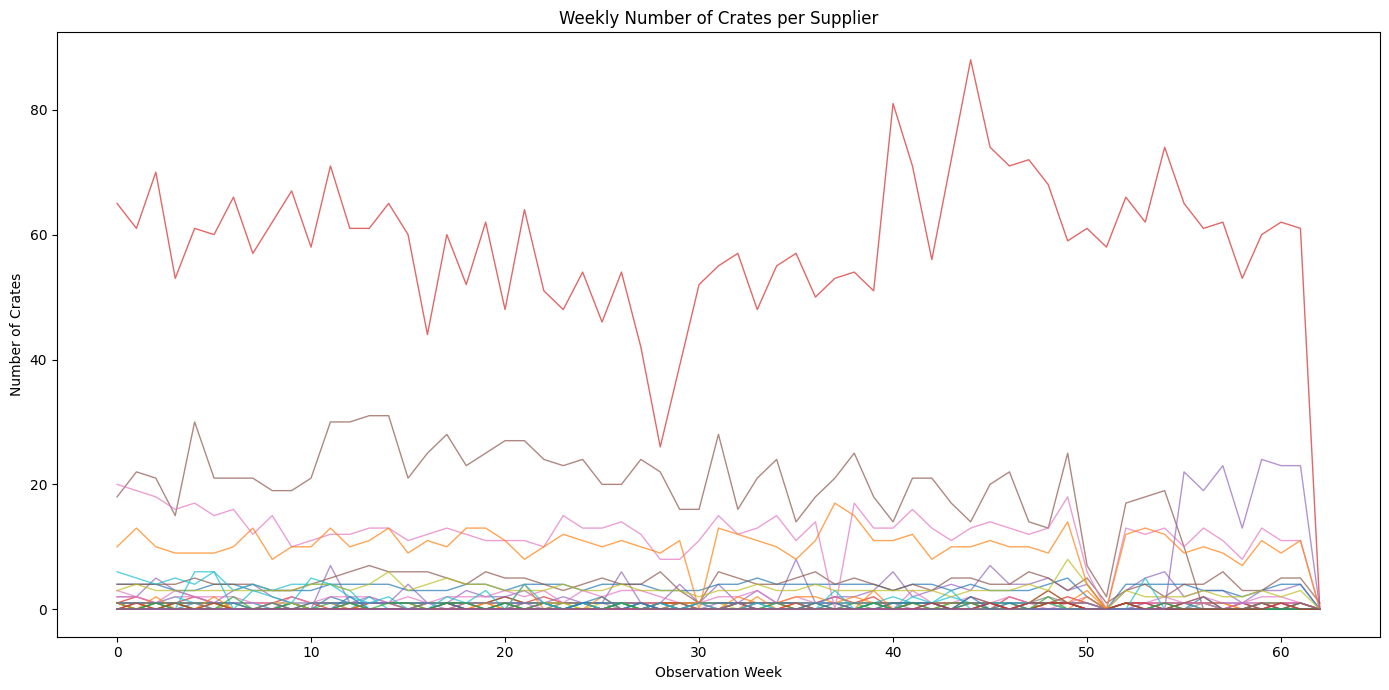

In [41]:
# 1. Build supplier-week level crate totals
# ============================================================================
# Aggregate across crate types to obtain total crates per supplier per week

supplier_week = (
    weekly_df.groupby(
        ["iso_year", "iso_week", "supplier_id"],
        as_index=False
    )["n_crates"]
    .sum()
    .rename(columns={"n_crates": "weekly_crates"})
)

# Create a unique week identifier for plotting
supplier_week["year_week"] = (
    supplier_week["iso_year"].astype(str)
    + "-W"
    + supplier_week["iso_week"].astype(str).str.zfill(2)
)

# 2. Network-level statistics
# ============================================================================

n_supplier_week_obs = len(supplier_week)

network_weekly = (
    supplier_week.groupby(["iso_year", "iso_week"])["weekly_crates"]
    .sum()
    .reset_index(name="network_crates")
)

avg_network_crates_per_week = network_weekly["network_crates"].mean()

print("=" * 80)
print("NETWORK-LEVEL RESULTS")
print("=" * 80)

print(f"Supplier-week observations: {n_supplier_week_obs:,}")
print(
    f"Average total crates collected per week across network: "
    f"{avg_network_crates_per_week:.2f}"
)


# 3. Crate concentration analysis
# ============================================================================

supplier_totals = (
    supplier_week.groupby("supplier_id")["weekly_crates"]
    .sum()
    .sort_values(ascending=False)
)

total_crates_network = supplier_totals.sum()

share_1044 = (
    supplier_totals.get(1044, 0)
    / total_crates_network
    * 100
)

top3_share = (
    supplier_totals.head(3).sum()
    / total_crates_network
    * 100
)

print("\n" + "=" * 80)
print("CRATE CONCENTRATION")
print("=" * 80)

print(f"Supplier 1044 share of all crates: {share_1044:.2f}%")
print(f"Top 3 suppliers share of all crates: {top3_share:.2f}%")

print("\nTop 10 suppliers by total crates:")
print(
    (
        supplier_totals.head(10)
        .to_frame("total_crates")
        .assign(
            share_pct=lambda x:
            100 * x["total_crates"] / total_crates_network
        )
    )
)

# Long-tail indicator
bottom_50_pct = int(np.ceil(len(supplier_totals) * 0.5))

tail_share = (
    supplier_totals.tail(bottom_50_pct).sum()
    / total_crates_network
    * 100
)

print(
    f"\nBottom 50% of suppliers account for "
    f"{tail_share:.2f}% of all crates."
)


# 4. Crate mix for supplier 1044
# ============================================================================

supplier_1044_mix = (
    weekly_df[weekly_df["supplier_id"] == 1044]
    .groupby("crate_type")["n_crates"]
    .sum()
    .sort_values(ascending=False)
)

print("\n" + "=" * 80)
print("SUPPLIER 1044 CRATE MIX")
print("=" * 80)

print(supplier_1044_mix)

# Check if supplier 1044 uses multiple crate types within weeks
weekly_mix_1044 = (
    weekly_df[weekly_df["supplier_id"] == 1044]
    .groupby(["iso_year", "iso_week"])["crate_type"]
    .nunique()
)

multi_type_weeks = (weekly_mix_1044 >= 3).sum()

print(
    f"\nWeeks where supplier 1044 used "
    f"3 or more crate types: {multi_type_weeks}"
)


# 5. Weekly variability (Coefficient of Variation)
# ============================================================================

supplier_stats = (
    supplier_week.groupby("supplier_id")["weekly_crates"]
    .agg(
        mean="mean",
        min="min",
        max="max",
        std="std",
        n_weeks="count"
    )
)

supplier_stats["cv"] = (
    supplier_stats["std"]
    / supplier_stats["mean"]
)

print("\n" + "=" * 80)
print("COEFFICIENT OF VARIATION")
print("=" * 80)

for supplier in [1343, 1016, 1044, 988]:
    if supplier in supplier_stats.index:
        cv = supplier_stats.loc[supplier, "cv"]
        mean = supplier_stats.loc[supplier, "mean"]

        print(
            f"Supplier {supplier}: "
            f"mean={mean:.2f}, CV={cv:.3f}"
        )


# 6. Table Y
# ============================================================================

table_y = (
    supplier_stats[["mean", "min", "max", "cv"]]
    .reset_index()
    .sort_values("mean", ascending=False)
)

print("\n" + "=" * 80)
print("TABLE Y - WEEKLY CRATE SUMMARY PER SUPPLIER")
print("=" * 80)

print(table_y.to_string(index=False))

# Optional export
table_y.to_excel(
    "supplier_weekly_crate_statistics.xlsx",
    index=False
)


# 7. Figure X - Weekly crates per supplier
# ============================================================================

pivot_plot = supplier_week.pivot_table(
    index=["iso_year", "iso_week"],
    columns="supplier_id",
    values="weekly_crates",
    fill_value=0
)

plt.figure(figsize=(14, 7))

for supplier in pivot_plot.columns:
    plt.plot(
        range(len(pivot_plot)),
        pivot_plot[supplier],
        linewidth=1,
        alpha=0.7,
        label=str(supplier)
    )

plt.title("Weekly Number of Crates per Supplier")
plt.xlabel("Observation Week")
plt.ylabel("Number of Crates")
plt.tight_layout()

plt.savefig(
    "weekly_crates_per_supplier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
####################################
## From Hub to Customer
#####################################

In [43]:
# Step 1:   Determine the crate type for the customer delivery leg.
#
#    Priority:
#      1. 'ieren' in product_name                 ->  Eierdoos (size from packaging_type).
#      2. fresh mushroom: name matches a mushroom term AND product_category is
#         'Vegetables'                            ->  Champignon kratje.
#         The Vegetables gate keeps processed mushroom snacks (e.g. oesterzwam
#         bitterballen / kroketten, categorised as Fry / ready-made) in CBL.
#      3. 'melk' in product_name                  ->  CBL  (milk is decanted at the hub).
#      4. Everything else                         ->  CBL.

# mushroom_terms is defined once in the crate-config cell (Section 10) and reused here.

def get_customer_crate_type(product_name: str, packaging_type, product_category) -> str:

    name = str(product_name).lower() if pd.notna(product_name) else ""
    pkg  = str(packaging_type).lower() if pd.notna(packaging_type) else ""
    cat  = str(product_category).lower() if pd.notna(product_category) else ""

    # Eggs - size comes from the packaging_type field
    if "ieren" in name:
        if "360" in pkg:
            return "Eierdoos 360 stuks"
        if "180" in pkg:
            return "Eierdoos 180 stuks"
        if "90" in pkg:
            return "Eierdoos 90 stuks"
        # Unknown egg-box size -> default CBL
        return "CBL"

    # Fresh mushrooms: only when the product is a vegetable, so processed
    # mushroom snacks (oesterzwam bitterballen/kroketten, etc.) stay in CBL.
    if cat == "vegetables" and any(term in name for term in mushroom_terms):
        return "Champignon kratje"

    # Milk: decanted at hub -> leaves the hub in CBL
    if "melk" in name:
        return "CBL"

    return "CBL"


# Step 2: Return (weight_capacity_kg, volume_capacity_m3).
def get_crate_specs(crate_name: str):

    weight_cap = CRATE_WEIGHT_CAPACITY_KG.get(crate_name, 27.0)
    dims = (
        CRATE_DIMENSIONS_MM.get(crate_name)
        or QUANTITY_BASED_CRATES.get(crate_name)
        or {"length": 600, "width": 400, "height": 230}
    )
    vol_cap = (
        (dims["length"] / 1000)
        * (dims["width"]  / 1000)
        * (dims["height"] / 1000)
    )
    return weight_cap, vol_cap
 
 
#  Step 3: FFD packing algorithm 
#
# Used for all crate types that are NOT in QUANTITY_BASED_CRATES.
#
# Algorithm (First-Fit Decreasing by volume):
#   • Sort rows by volume DESC — largest item is packed first.
#   • Place each item into the current open crate if it still fits by volume.
#   • After placing, check cumulative weight; if it exceeds the cap, move the
#     offending item into a new crate (it "spills over").
#   • If a single item's volume exceeds one full crate, it gets its own crate.
 
def pack_rows_ffd(volumes: list, weights: list,
                  weight_cap: float, vol_cap: float) -> list:
    n = len(volumes)
    if n == 0:
        return []

    sorted_idx = sorted(range(n), key=lambda i: volumes[i], reverse=True)
    crate_vol, crate_wt = [], []          # running totals per open crate
    assignment = [None] * n

    for orig_i in sorted_idx:
        v, w = volumes[orig_i], weights[orig_i]
        placed = False
        for c in range(len(crate_vol)):
            if crate_vol[c] + v <= vol_cap and crate_wt[c] + w <= weight_cap:
                crate_vol[c] += v
                crate_wt[c]  += w
                assignment[orig_i] = c + 1            # 1-based, never skips
                placed = True
                break
        if not placed:                                # too heavy/bulky for any crate,
            crate_vol.append(v)                       # or larger than one crate → own crate
            crate_wt.append(w)
            assignment[orig_i] = len(crate_vol)
    return assignment
 
 
# Step 4: Adding the crates to each row
df_crate["customer_crate_type"] = df_crate.apply(
    lambda r: get_customer_crate_type(
        r["product_name"], r.get("packaging_type"), r.get("product_category")
    ), axis=1
)

df_crate["customer_crate_number"]        = None
df_crate["customer_crate_weight_cap_kg"] = None
df_crate["customer_crate_vol_cap_m3"]    = None

customer_results = []
for (cust_id, crate_name), grp in df_crate.groupby(["customer_order_id", "customer_crate_type"]):
    weight_cap, vol_cap = get_crate_specs(crate_name)

    if crate_name in QUANTITY_BASED_CRATES:                  # eggs → 1 crate per unit
        n_crates = int(grp["quantity_units"].fillna(0).sum())
        numbers  = {idx: 1 for idx in grp.index}             # per-row number not meaningful
    else:                                                    # CBL / champignon → FFD
        volumes    = grp["line_volume_m3"].fillna(0).tolist()
        weights    = grp["line_weight_kg"].fillna(0).tolist()
        assignment = pack_rows_ffd(volumes, weights, weight_cap, vol_cap)
        numbers    = {idx: assignment[i] for i, idx in enumerate(grp.index)}
        n_crates   = max(assignment) if assignment else 0

    for idx in grp.index:
        df_crate.at[idx, "customer_crate_number"]        = numbers[idx]
        df_crate.at[idx, "customer_crate_weight_cap_kg"] = weight_cap
        df_crate.at[idx, "customer_crate_vol_cap_m3"]    = round(vol_cap, 4)

    customer_results.append({
        "iso_year":          grp["iso_year"].iloc[0],
        "iso_week":          grp["iso_week"].iloc[0],
        "customer_order_id": cust_id,
        "crate_type":        crate_name,
        "n_items":           len(grp),
        "total_weight_kg":   round(grp["line_weight_kg"].fillna(0).sum(), 3),
        "total_volume_m3":   round(grp["line_volume_m3"].fillna(0).sum(), 4),
        "weight_cap_kg":     weight_cap,
        "vol_cap_m3":        round(vol_cap, 4),
        "n_crates":          n_crates,
    })

df_crate["customer_crate_number"] = df_crate["customer_crate_number"].astype(int)

# Step 5: Summary
# Long summary: one row per (customer order × crate type)
customer_summary_df = (
    pd.DataFrame(customer_results)
    .sort_values(["iso_year", "iso_week", "customer_order_id", "crate_type"])
    .reset_index(drop=True)
)

# Pivot: crates per crate type for each order (+ row total)
customer_pivot = customer_summary_df.pivot_table(
    index="customer_order_id", columns="crate_type",
    values="n_crates", aggfunc="sum", fill_value=0
)
customer_pivot["Total crates"] = customer_pivot.sum(axis=1)

# Step 6: Adding it to new excel 
cust_trace_cols = [
    "iso_year", "iso_week", "supplier_id",
    "customer_order_id", "order_item_id", "product_name", "product_category",
    "quantity_units", "pkg_unit", "pkg_amount",
    "line_weight_kg", "line_volume_m3",
    "customer_crate_type", "customer_crate_weight_cap_kg",
    "customer_crate_vol_cap_m3", "customer_crate_number",
]
cust_trace_cols = [c for c in cust_trace_cols if c in df_crate.columns]
df_cust_trace = df_crate[cust_trace_cols].sort_values(
    ["customer_order_id", "customer_crate_type", "customer_crate_number"]
)

output_path_cust = "crate_calculation_customer.xlsx"
with pd.ExcelWriter(output_path_cust, engine="openpyxl") as writer:
    customer_summary_df.to_excel(writer, sheet_name="Per Customer Order", index=False)
    customer_pivot.to_excel(writer,      sheet_name="Customer Pivot")
    df_cust_trace.to_excel(writer,       sheet_name="Crate Assignment",  index=False)
    wb = writer.book
    for sheet_name in ["Per Customer Order", "Crate Assignment"]:
        style_sheet(wb[sheet_name])

print(f"Saved → {output_path_cust}")
print("Sheets: 'Per Customer Order' | 'Customer Pivot' | 'Crate Assignment'")
print(f"Orders processed: {customer_summary_df['customer_order_id'].nunique()}")

Saved → crate_calculation_customer.xlsx
Sheets: 'Per Customer Order' | 'Customer Pivot' | 'Crate Assignment'
Orders processed: 1711


In [44]:
# ============================================================================
# 1. Order-level and network-level summary
# ============================================================================

n_customer_orders = customer_summary_df["customer_order_id"].nunique()

# total crates per order
order_totals = (
    customer_summary_df.groupby("customer_order_id")["n_crates"]
    .sum()
    .reset_index(name="total_crates")
)

avg_crates_per_order = order_totals["total_crates"].mean()

# weekly aggregation (customer side)
customer_summary_df["week_key"] = (
    customer_summary_df["iso_year"].astype(str)
    + "-W"
    + customer_summary_df["iso_week"].astype(str).str.zfill(2)
)

weekly_customer = (
    customer_summary_df.groupby(["iso_year", "iso_week"])["n_crates"]
    .sum()
    .reset_index(name="weekly_crates")
)

avg_crates_per_customer_week = weekly_customer["weekly_crates"].mean()

print("=" * 80)
print("CUSTOMER-LINE RESULTS")
print("=" * 80)
print(f"Customer orders processed: {n_customer_orders:,}")
print(f"Average crates per customer order: {avg_crates_per_order:.2f}")
print(f"Average crates per customer-week: {avg_crates_per_customer_week:.2f}")

# ============================================================================
# 2. Concentration: customer-side crate demand
# ============================================================================

customer_totals = (
    order_totals.groupby("customer_order_id")["total_crates"]
    .sum()
    .sort_values(ascending=False)
)

total_crates_customer = customer_totals.sum()

top1_share = customer_totals.head(1).sum() / total_crates_customer * 100
top5_share = customer_totals.head(5).sum() / total_crates_customer * 100
top10_share = customer_totals.head(10).sum() / total_crates_customer * 100

print("\n" + "=" * 80)
print("CUSTOMER CONCENTRATION")
print("=" * 80)
print(f"Top 1 customer share: {top1_share:.2f}%")
print(f"Top 5 customers share: {top5_share:.2f}%")
print(f"Top 10 customers share: {top10_share:.2f}%")

# ============================================================================
# 3. Crate mix homogeneity (CBL dominance)
# ============================================================================

crate_mix = (
    customer_summary_df.groupby("crate_type")["n_crates"]
    .sum()
    .sort_values(ascending=False)
)

crate_mix_share = (crate_mix / crate_mix.sum()) * 100

print("\n" + "=" * 80)
print("DELIVERY CRATE MIX")
print("=" * 80)
print(crate_mix.to_string())
print("\nShare (%):")
print(crate_mix_share.round(2).to_string())

# share of CBL dominance
cbl_share = crate_mix_share.get("CBL", 0)
print(f"\nCBL share of all delivery crates: {cbl_share:.2f}%")

# ============================================================================
# 4. Comparison: supplier-side vs customer-side totals (hub effect)
# ============================================================================

if "weekly_df" in globals():

    supplier_total_crates = weekly_df["n_crates"].sum()
    customer_total_crates = customer_summary_df["n_crates"].sum()

    diff = customer_total_crates - supplier_total_crates
    pct_change = diff / supplier_total_crates * 100

    print("\n" + "=" * 80)
    print("HUB CONSOLIDATION EFFECT")
    print("=" * 80)
    print(f"Supplier-side total crates: {supplier_total_crates:,.0f}")
    print(f"Customer-side total crates: {customer_total_crates:,.0f}")
    print(f"Net change (customer - supplier): {diff:,.0f}")
    print(f"Percentage change: {pct_change:.2f}%")

# ============================================================================
# 5. Customer variability (optional for Figure X)
# ============================================================================

customer_weekly_pivot = customer_summary_df.pivot_table(
    index=["iso_year", "iso_week"],
    columns="customer_order_id",
    values="n_crates",
    aggfunc="sum",
    fill_value=0
)

# optional plot-ready structure
print("\nWeekly customer matrix created for Figure X:")
print(customer_weekly_pivot.shape)

CUSTOMER-LINE RESULTS
Customer orders processed: 1,711
Average crates per customer order: 2.60
Average crates per customer-week: 70.57

CUSTOMER CONCENTRATION
Top 1 customer share: 0.47%
Top 5 customers share: 2.14%
Top 10 customers share: 4.00%

DELIVERY CRATE MIX
crate_type
CBL                   3230
Eierdoos 90 stuks      548
Eierdoos 360 stuks     423
Eierdoos 180 stuks     141
Champignon kratje      104

Share (%):
crate_type
CBL                   72.65
Eierdoos 90 stuks     12.33
Eierdoos 360 stuks     9.51
Eierdoos 180 stuks     3.17
Champignon kratje      2.34

CBL share of all delivery crates: 72.65%

HUB CONSOLIDATION EFFECT
Supplier-side total crates: 8,062
Customer-side total crates: 4,446
Net change (customer - supplier): -3,616
Percentage change: -44.85%

Weekly customer matrix created for Figure X:
(63, 1711)


## 11. Validation

In [45]:
# ----------------------------------------------------------------------------
# Re-runs the crate calculation while scaling one uncertain input at a time
# (others held at their baseline value) and reports how the TOTAL number of
# crates changes. Reuses the existing packers, get_crate_specs, the category
# tables and df_crate from Section 10 (run this AFTER Section 10).
#
# Inputs varied (each multiplied by a factor):
#   - Density (CATEGORY_DENSITY)            -> volume = mass / density
#   - Packing factor (CATEGORY_PACKING...)  -> volume multiplier
#   - Line weight (line_weight_kg)          -> weight constraint + stuks volume
#   - Crate weight capacity                 -> from get_crate_specs
#   - Crate volume capacity                 -> from get_crate_specs
# ============================================================================

def _total_crates(density_mult=1.0, packing_mult=1.0, weight_mult=1.0,
                  weightcap_mult=1.0, volcap_mult=1.0):
    """Return (supplier_total, customer_total) crate counts under scaled inputs."""
    dens = {k: v * density_mult for k, v in CATEGORY_DENSITY.items()}
    pack = {k: v * packing_mult for k, v in CATEGORY_PACKING_FACTOR.items()}

    df = df_crate.copy()
    df["line_weight_kg"] = df["line_weight_kg"] * weight_mult   # scale weights first

    # recompute line_volume_m3 with scaled density/packing (mirrors Section 9)
    def _vol(row):
        q, pa, pu, cat = (row["quantity_units"], row["pkg_amount"],
                          row["pkg_unit"], row["product_category"])
        if pd.notna(pa) and pa > 0:
            d, p = dens[cat], pack[cat]
            if pu == "kg":
                return q * (pa / d) * p
            if pu == "L":
                return q * (pa / 1000) * p
            if pu == "stuks":
                w = row["line_weight_kg"]
                if pd.notna(w) and w > 0:
                    return (w / d) * p
        return None
    df["line_volume_m3"] = df.apply(_vol, axis=1)

    def _count(group_cols, uses_df_packer):
        total = 0
        for keys, grp in df.groupby(group_cols):
            crate_name = keys[-1]                       # crate type is the last key
            wcap, vcap = get_crate_specs(crate_name)
            wcap *= weightcap_mult
            vcap *= volcap_mult
            if crate_name in QUANTITY_BASED_CRATES:     # eggs/milk: counted by units
                total += int(grp["quantity_units"].fillna(0).sum())
            elif uses_df_packer:                        # supplier leg packer
                a = pack_rows_into_crates(grp, wcap, vcap)
                total += max(a) if a else 0
            else:                                       # customer leg packer
                a = pack_rows_ffd(grp["line_volume_m3"].fillna(0).tolist(),
                                  grp["line_weight_kg"].fillna(0).tolist(),
                                  wcap, vcap)
                total += max(a) if a else 0
        return total

    supplier_total = _count(["iso_year", "iso_week", "supplier_id", "crate_type"], True)
    customer_total = _count(["customer_order_id", "customer_crate_type"], False)
    return supplier_total, customer_total


# ---- baseline (all multipliers = 1.0) ----
base_sup, base_cust = _total_crates()
base_tot = base_sup + base_cust
print("BASELINE total crates")
print(f"  supplier -> hub : {base_sup}")
print(f"  hub -> customer : {base_cust}")
print(f"  combined        : {base_tot}\n")

# ---- one-at-a-time sweep ----
params = {
    "Density":              "density_mult",
    "Packing factor":       "packing_mult",
    "Line weight":          "weight_mult",
    "Crate weight cap":     "weightcap_mult",
    "Crate volume cap":     "volcap_mult",
}
multipliers = [0.8, 0.9, 1.0, 1.1, 1.2]

print(f"{'Parameter':18s}{'x':>6}{'supplier':>11}{'customer':>11}{'combined':>11}{'Δ% comb':>10}")
print("-" * 67)
summary = {}
for label, arg in params.items():
    lo_hi = []
    for m in multipliers:
        sup, cust = _total_crates(**{arg: m})
        tot = sup + cust
        d = 100 * (tot - base_tot) / base_tot if base_tot else 0.0
        mark = "  (baseline)" if m == 1.0 else ""
        print(f"{label:18s}{m:>6.2f}{sup:>11}{cust:>11}{tot:>11}{d:>9.1f}%{mark}")
        lo_hi.append(d)
    summary[label] = (min(lo_hi), max(lo_hi))
    print("-" * 67)

# ---- ranked sensitivity (tornado) ----
print("\nSensitivity ranking (Δ% in combined crates over the ±20% range):")
for label, (lo, hi) in sorted(summary.items(), key=lambda kv: (kv[1][1] - kv[1][0]), reverse=True):
    span = hi - lo
    print(f"  {label:18s} {lo:+6.1f}% … {hi:+6.1f}%   (span {span:4.1f} pts)")

BASELINE total crates
  supplier -> hub : 8062
  hub -> customer : 4446
  combined        : 12508

Parameter              x   supplier   customer   combined   Δ% comb
-------------------------------------------------------------------
Density             0.80       8118       4465      12583      0.6%
Density             0.90       8082       4457      12539      0.2%
Density             1.00       8062       4446      12508      0.0%  (baseline)
Density             1.10       8055       4448      12503     -0.0%
Density             1.20       8050       4447      12497     -0.1%
-------------------------------------------------------------------
Packing factor      0.80       8049       4446      12495     -0.1%
Packing factor      0.90       8054       4446      12500     -0.1%
Packing factor      1.00       8062       4446      12508      0.0%  (baseline)
Packing factor      1.10       8082       4453      12535      0.2%
Packing factor      1.20       8160       4464      12624    